In [1]:
# Configuración inicial
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import requests
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pickle

# Configurar semilla aleatoria para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Verificar versión de TensorFlow
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [2]:
# Descargar el dataset
url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
response = requests.get(url, stream=True)

# Guardar el archivo
with open('flower_photos.tgz', 'wb') as file:
    for chunk in response.iter_content(chunk_size=8192):
        file.write(chunk)

print("Descarga completada")

# Extraer el archivo
import tarfile
with tarfile.open('flower_photos.tgz', 'r:gz') as tar:
    tar.extractall()

print("Extracción completada")

# Verificar estructura del dataset
data_dir = 'flower_photos'
classes = os.listdir(data_dir)
classes = [c for c in classes if os.path.isdir(os.path.join(data_dir, c))]
print("Clases encontradas:", classes)

# Contar imágenes por clase
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
    print(f"{class_name}: {num_images} imágenes")

Descarga completada


/tmp/ipykernel_880/1529616472.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Extracción completada
Clases encontradas: ['roses', 'tulips', 'daisy', 'sunflowers', 'dandelion']
roses: 641 imágenes
tulips: 799 imágenes
daisy: 633 imágenes
sunflowers: 699 imágenes
dandelion: 898 imágenes


In [3]:
# Parámetros de preprocesamiento
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
NUM_CLASSES = len(classes)

# Generador para entrenamiento con aumento de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Generador para validación (solo normalización)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Crear generadores de datos
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Verificar clases
class_indices = train_generator.class_indices
print("Mapeo de clases:", class_indices)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Mapeo de clases: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,944,069 (26.49 MB)

 Trainable params: 6,944,069 (26.49 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stop]
)

model.save('flower_model.keras')
print("Modelo guardado")

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 316ms/step - accuracy: 0.3590 - loss: 1.4105 - val_accuracy: 0.4555 - val_loss: 1.3041
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.4920 - loss: 1.1735 - val_accuracy: 0.5445 - val_loss: 1.0811
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 246ms/step - accuracy: 0.5733 - loss: 1.0536 - val_accuracy: 0.6101 - val_loss: 1.0019
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 242ms/step - accuracy: 0.6240 - loss: 0.9624 - val_accuracy: 0.6170 - val_loss: 0.9801
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.6519 - loss: 0.9213 - val_accuracy: 0.6293 - val_loss: 0.9180
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.6543 - loss: 0.8868 - val_accuracy: 0.6334 - val_loss: 1.1071
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.6737 - loss: 0.8432 - val_accuracy: 0.6525 - val_loss: 0.8698
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.6873 - loss: 0.8173 - val_accu

In [6]:
from google.colab import drive
import shutil

# Montar Drive
drive.mount('/content/drive')

# Crear carpeta en Drive
os.makedirs('/content/drive/MyDrive/flower_classifier', exist_ok=True)

# Copiar modelo a Drive
shutil.copy('flower_model.keras', '/content/drive/MyDrive/flower_classifier/flower_model.keras')
print("✅ Modelo copiado a Google Drive")

Mounted at /content/drive
✅ Modelo copiado a Google Drive


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7483 - loss: 0.7207
Precisión en validación: 0.7483
Pérdida en validación: 0.7207


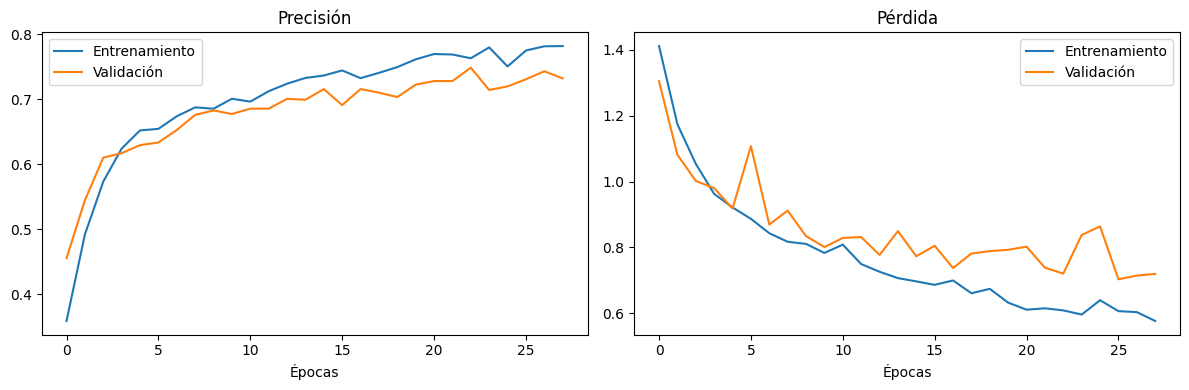

In [7]:
# Evaluación
test_loss, test_acc = model.evaluate(validation_generator)
print(f"Precisión en validación: {test_acc:.4f}")
print(f"Pérdida en validación: {test_loss:.4f}")

# Gráficas
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.legend()

plt.tight_layout()
plt.show()